# Imports and Raw Data Processing

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
# Usage
base_dir = "../experiment14[depol-time-evo-noisy_variousorderzne_tmax_20]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)
EXACT_SOL: float = -8.566772233505624

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

In [4]:
RAW_SIM_DATA.keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

Processing ZNE data for plotting.

In [23]:
# ============================================================================
# DATA PROCESSING
# ============================================================================

def _process_vqe_noiseoff(content: dict) -> dict:
    nf_folder = content.get("VQE_noiseoff", {})
    nf_costs  = []
    for k, run in nf_folder.items():
        if not run or "REDUNDANT" in k or "output" not in run:
            continue
        try:
            nf_costs.append(run["output"]["optimized_minimum_cost"][0])
        except (KeyError, IndexError, TypeError):
            continue

    stats = {
        "mean": float(np.mean(nf_costs)) if nf_costs else None,
        "std":  float(np.std(nf_costs))  if nf_costs else None,
    }
    print(f"✅ VQE_noiseoff: {len(nf_costs)} runs aggregated, mean={stats['mean']}")
    return stats


def _extract_single_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-single-var runs.

    JSON structure:
        zne_values.others.sorted_noise
        zne_values.others.sorted_expectation_vals
        zne_values.others.beta_coeffiecients   (sic — typo in source JSON)
        zne_values.others.cost_richardson_zne
        zne_values.extrapolated_value
    """
    zne_vals = run["output"].get("zne_values", {})
    others   = zne_vals.get("others", {})

    noise   = others.get("sorted_noise")            or zne_vals.get("sorted_noise")
    y_vals  = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
    ext_val = zne_vals.get("extrapolated_value")
    betas   = others.get("beta_coeffiecients")      # typo preserved from source JSON
    cost    = others.get("cost_richardson_zne")

    if noise and y_vals and ext_val is not None:
        return noise, y_vals, ext_val, betas, cost
    return None


def _extract_mul_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-mul-var runs.

    JSON structure:
        zne_values.sampled data  : [[n1,n2,n3,val], ...]
        zne_values.extrapolated_value
    """
    zne_vals = run["output"].get("zne_values", {})
    sampled  = zne_vals.get("sampled data", [])
    ext_val  = zne_vals.get("extrapolated_value")

    if not sampled or ext_val is None:
        return None

    noise  = [row[:-1] for row in sampled]
    y_vals = [row[-1]  for row in sampled]

    order  = sorted(range(len(noise)), key=lambda i: sum(noise[i]))
    noise  = [noise[i]  for i in order]
    y_vals = [y_vals[i] for i in order]

    return noise, y_vals, ext_val, None, None


def _process_zne_folder(zne_folder: dict, zne_key: str, nf_stats: dict, extractor) -> dict:
    result = {}

    for label, runs in zne_folder.items():
        ext_vals, all_y_curves = [], []
        all_betas, all_costs   = [], []
        noise_levels = None
        tmax         = None

        for k, run in runs.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue

            extracted = extractor(run)
            if extracted is None:
                print(f"⚠️ Skipping ZNE/{zne_key}/{label}/{k}: Missing required keys.")
                continue

            noise, y_vals, ext_val, betas, cost = extracted
            tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]

            ext_vals.append(ext_val)
            all_y_curves.append(y_vals)
            if betas is not None: all_betas.append(betas)
            if cost  is not None: all_costs.append(cost)
            if noise_levels is None:
                noise_levels = noise

        if ext_vals and all_y_curves:
            y_array = np.array(all_y_curves)
            result[label] = {
                "noise_type":     "depolarizing",
                "tmax":           tmax,
                "exact_sol":      EXACT_SOL,
                "sorted_noise":   noise_levels,
                "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                "zne_mean":       float(np.mean(ext_vals)),
                "zne_std":        float(np.std(ext_vals)),
                "mean_noise_off": nf_stats["mean"],
                "std_noise_off":  nf_stats["std"],
                # single-var only (None for mul-var)
                "beta_mean":      np.mean(all_betas, axis=0).tolist() if all_betas else None,
                "beta_std":       np.std(all_betas,  axis=0).tolist() if all_betas else None,
                "cost_mean":      float(np.mean(all_costs)) if all_costs else None,
                "cost_std":       float(np.std(all_costs))  if all_costs else None,
            }
            print(f"✅ ZNE/{zne_key}/{label}: {len(ext_vals)} runs processed")
            #print(all_costs)
        else:
            print(f"❌ Failed to process ZNE/{zne_key}/{label}: No valid runs found")
    
    return result


def process_for_master_plotting(raw_data: dict) -> dict:
    """
    Main entry point. Expects:

        raw_data/
        └── data/
            ├── VQE/
            ├── VQE_noiseoff/
            └── ZNE/
                ├── ZNE-single-var/
                │   ├── ric2/ ... ricN/
                └── ZNE-mul-var/
                    ├── muld1/ ... muldN/

    Returns:
        {
            "ZNE-single-var": { "ric2": {...}, ... },
            "ZNE-mul-var":    { "muld1": {...}, ... },
        }
    """
    processed = {}
    content   = raw_data.get("data", raw_data)

    # 1. VQE_noiseoff
    nf_stats = _process_vqe_noiseoff(content)

    # 2. ZNE folders
    zne_root = content.get("ZNE", {})
    if not zne_root:
        print("❌ No ZNE folder found in data.")
        return processed

    ZNE_FOLDERS = {
        "ZNE-single-var": _extract_single_var_run,
        "ZNE-mul-var":    _extract_mul_var_run,
    }

    for zne_key, extractor in ZNE_FOLDERS.items():
        zne_folder = zne_root.get(zne_key, {})
        if not zne_folder:
            print(f"⚠️ No data found for ZNE/{zne_key}, skipping.")
            continue
        print(f"✅ ZNE/{zne_key} labels found: {list(zne_folder.keys())}")
        processed[zne_key] = _process_zne_folder(zne_folder, zne_key, nf_stats, extractor)

    return processed

In [24]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

✅ VQE_noiseoff: 10 runs aggregated, mean=-8.435520319786601
✅ ZNE/ZNE-single-var labels found: ['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2']
✅ ZNE/ZNE-single-var/ric6: 10 runs processed
✅ ZNE/ZNE-single-var/ric7: 10 runs processed
✅ ZNE/ZNE-single-var/ric5: 10 runs processed
✅ ZNE/ZNE-single-var/ric3: 10 runs processed
✅ ZNE/ZNE-single-var/ric4: 10 runs processed
✅ ZNE/ZNE-single-var/ric2: 10 runs processed
✅ ZNE/ZNE-mul-var labels found: ['muld2', 'muld1', 'muld3']
✅ ZNE/ZNE-mul-var/muld2: 10 runs processed
✅ ZNE/ZNE-mul-var/muld1: 10 runs processed
✅ ZNE/ZNE-mul-var/muld3: 10 runs processed


dict_keys(['ZNE-single-var', 'ZNE-mul-var'])

In [20]:
PROCESSED_SIM_DATA.keys()

dict_keys(['ZNE-single-var', 'ZNE-mul-var'])

# Plotting

In [8]:
width_px = 2048
height_px = 1554
dpi = 600

FIG_SIZE_IEEE = (width_px / dpi, height_px / dpi)
# (3.4133, 2.59) inches

## Single Variate ZNE

In [9]:
# Output directory to save plot figures
OUTPUT_DIR = "reports"
COLORS = {
    "noisy":      "#1f77b4",
    "zne":        "#ff7f0e",
    "exact":      "#d62728",
    "noise_free": "#0000ff",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'depolarizing',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47, 81, 115],
 'mean_exp_vals': [-6.201563991993811,
                   -2.9953345060519347,
                   -1.5150182758416424,
                   -0.7925463234618297],
 'std_exp_vals': [0.11133119201572951,
                  0.1744840700806796,
                  0.14562284379920612,
                  0.1073737011248071],
 'zne_mean': -8.08675111458275,
 'zne_std': 0.051464454626421345,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368,
 'beta_mean': [1.8564904335436592,
               -1.540492061876653,
               0.8938657642987986,
               -0.20986413596580494],
 'beta_std': [2.220446049250313e-16,
              2.220446049250313e-16,
              1.1102230246251565e-16,
              2.7755575615628914e-17],
 'cost_mean': 6.662711482694253,
 'cost_std': 0.0}


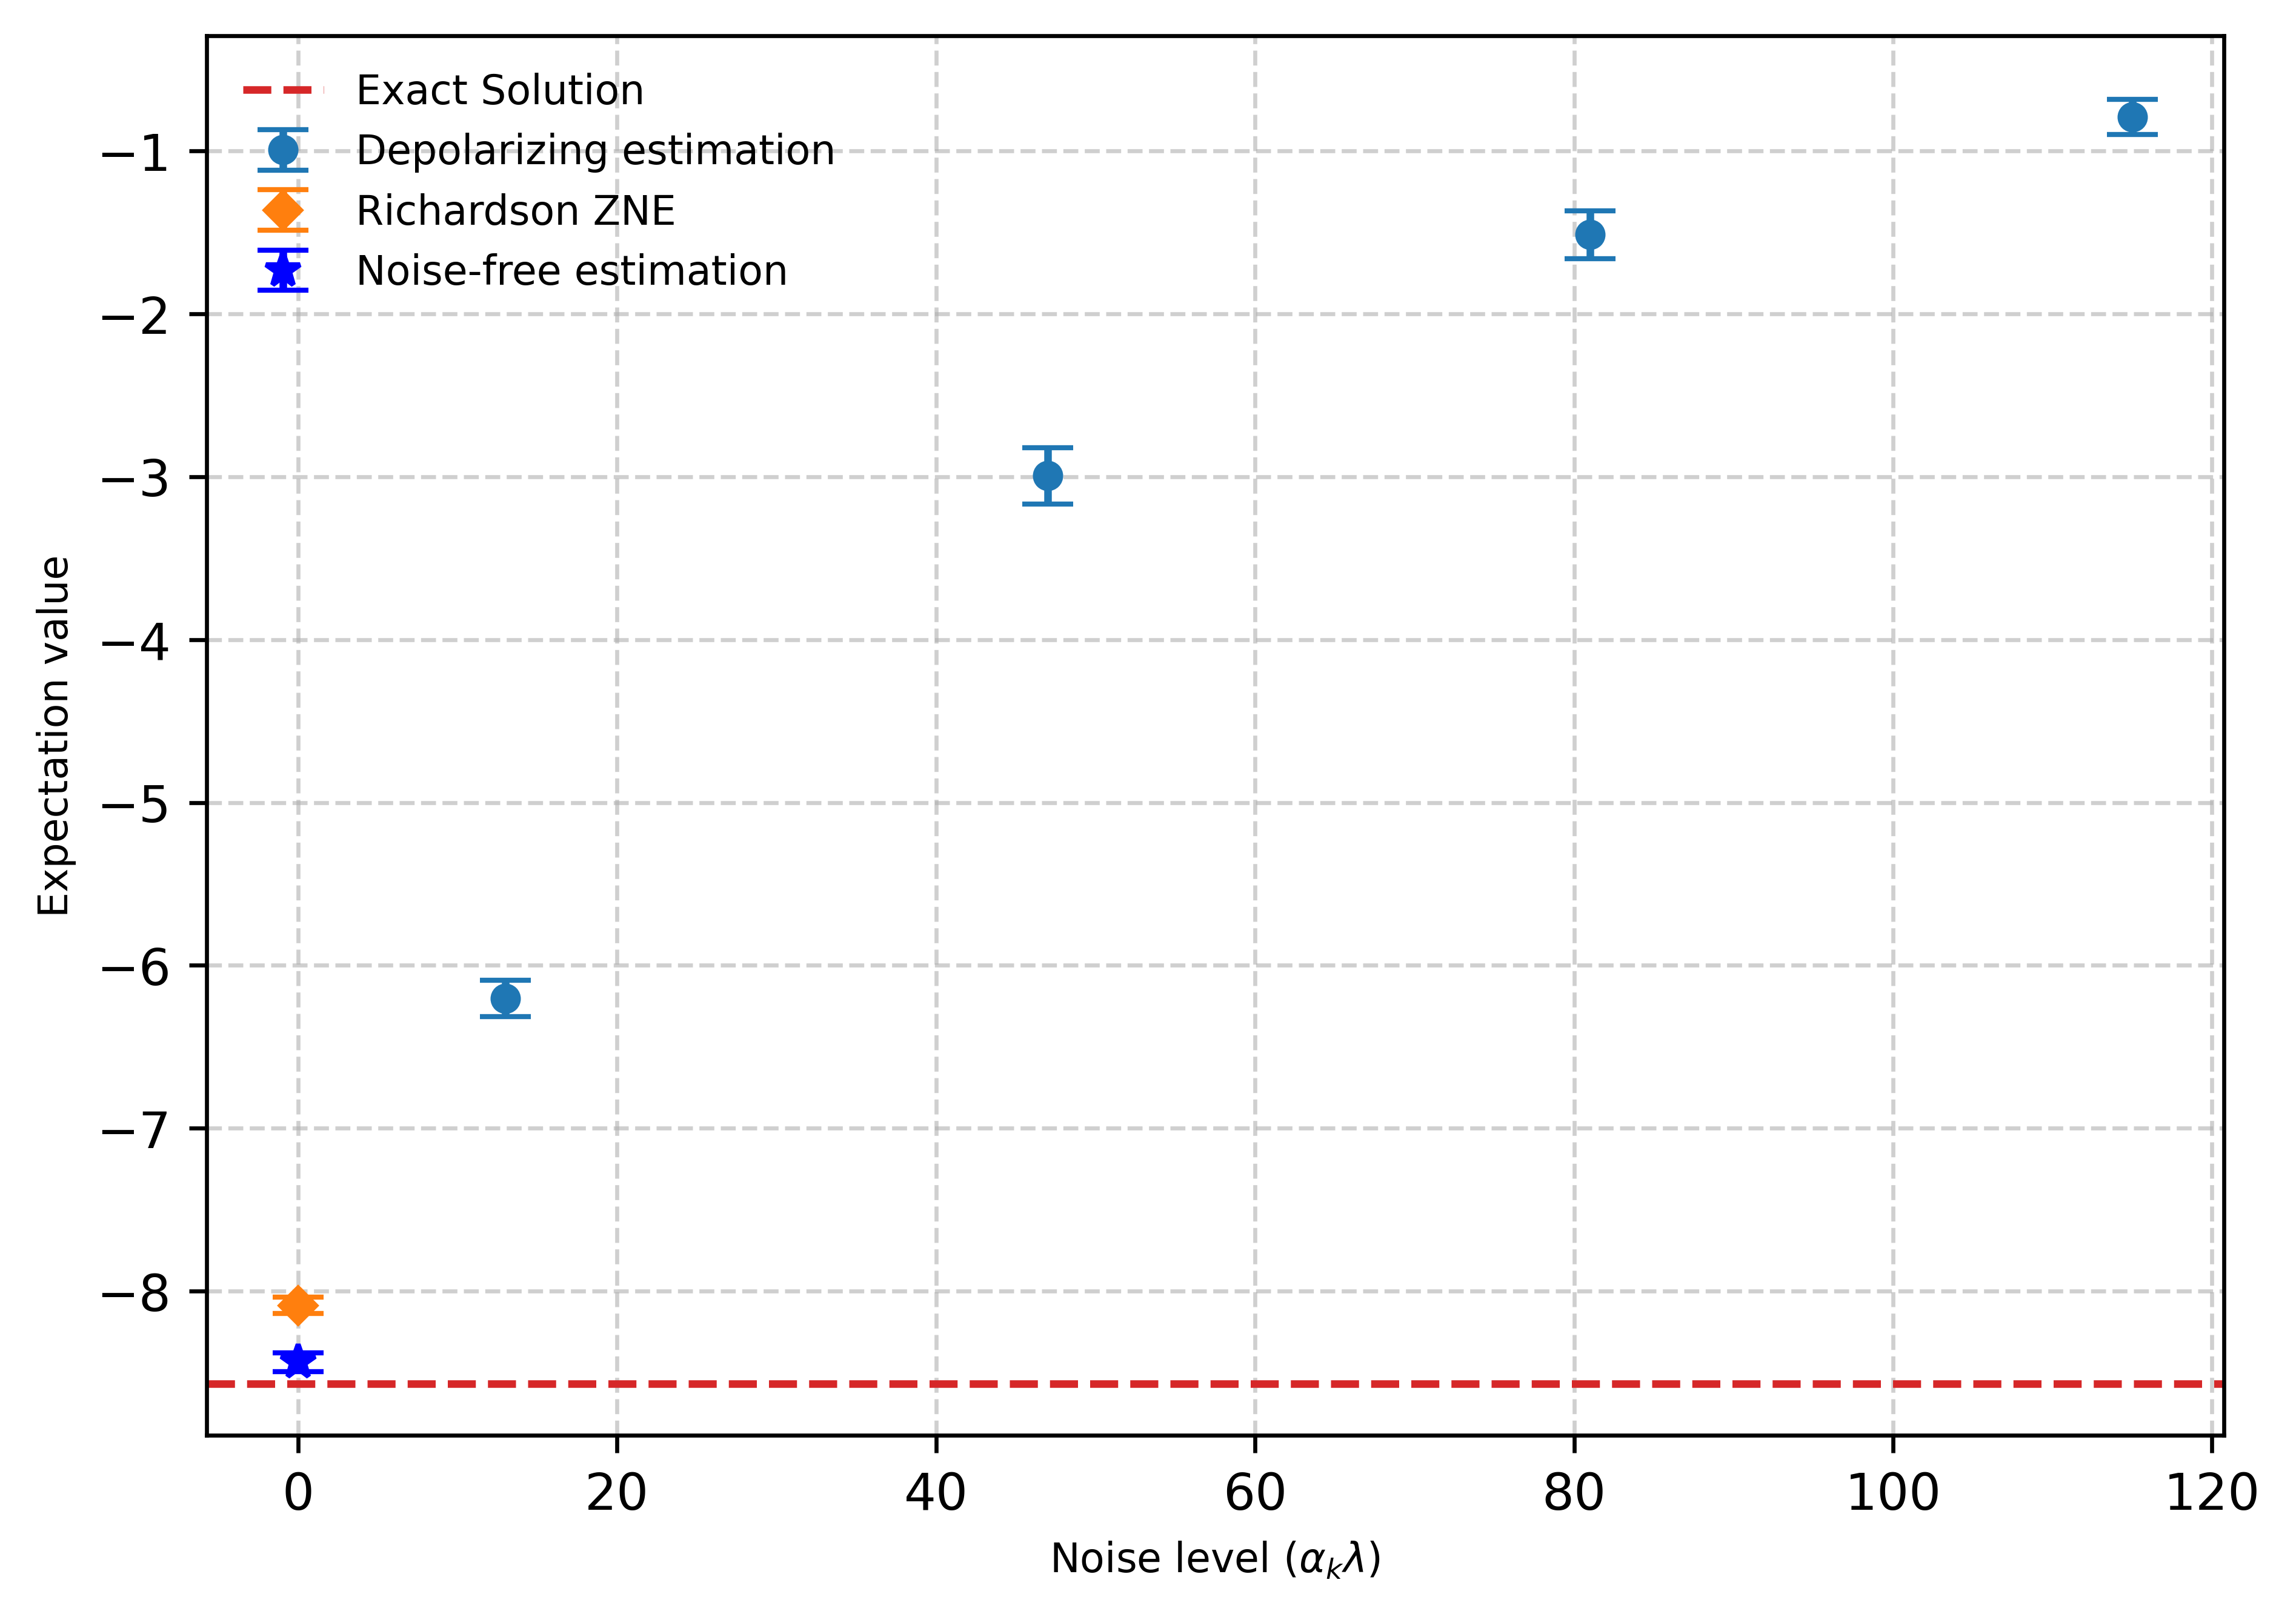

In [10]:
fig = plot_single_zne(
    data=PROCESSED_SIM_DATA["ZNE-single-var"]["ric4"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

In [11]:
type(PROCESSED_SIM_DATA.keys())

dict_keys

In [12]:
FIG_SIZE_IEEE

(3.4133333333333336, 2.59)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports' folder): xy-depol-diff-orders.eps


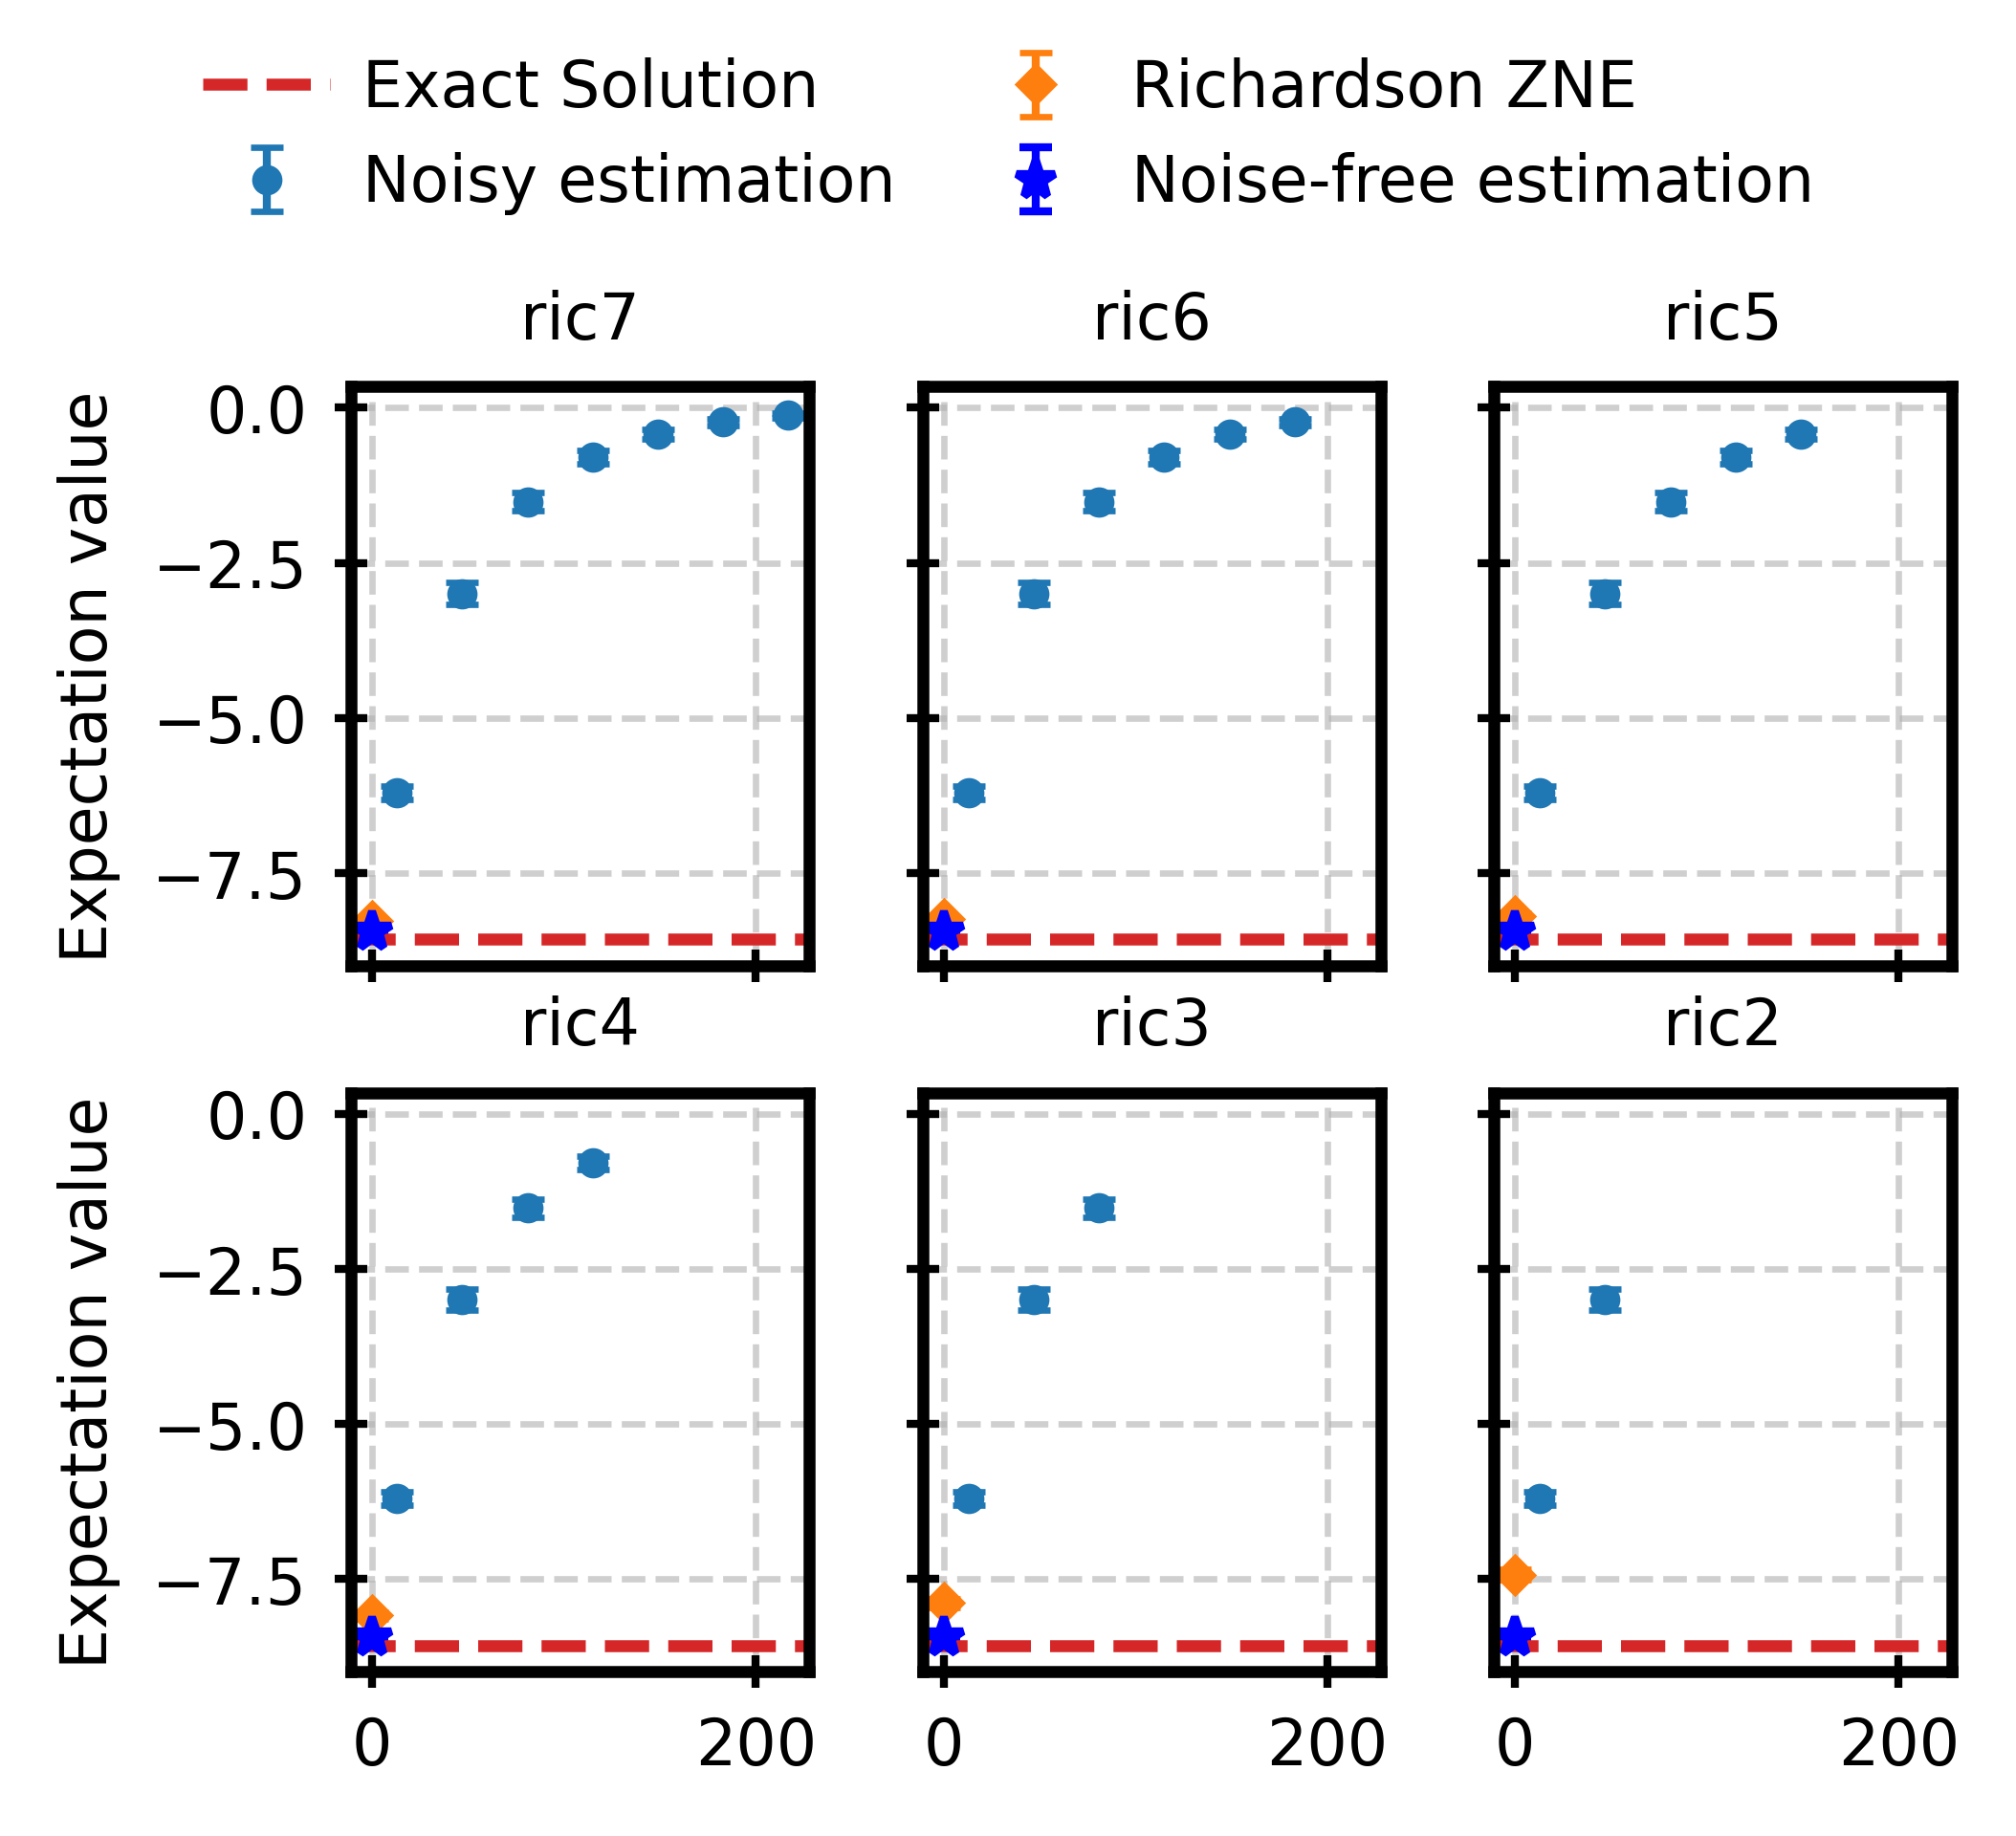

In [13]:
# pick which subcategories to include and in which order
subkeys = ["ric7", "ric6", "ric5", "ric4", "ric3", "ric2"]  # or specify a subset like ["ric2", "ric3", "ric4", "ric5", "ric6"]

data_list   = [PROCESSED_SIM_DATA["ZNE-single-var"][k] for k in subkeys]
plot_titles = subkeys   # or any custom labels you want per panel

fig = plot_multi_zne(
    data_list             = data_list,
    plot_titles           = subkeys,
    sharex                = True,
    plot_colors           = COLORS,
    xlabel = None,
    ylabel = "Expectation value",
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "xy-depol-diff-orders",
    output_dir            = OUTPUT_DIR,
    #plot_titles           = ["(a)", "(b)", "(c)"],
    #panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    #legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)

Cost of single variate Richardon extrapolation

In [28]:
PROCESSED_SIM_DATA["ZNE-single-var"].keys()

dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

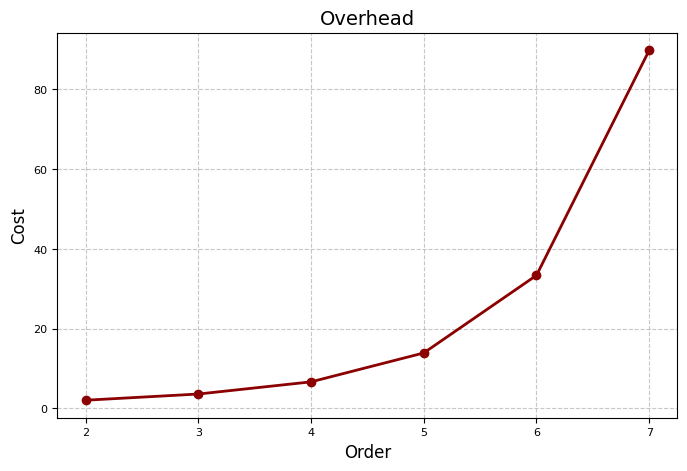

In [35]:
# Data extraction and sorting
x_vals = [len(v['sorted_noise']) for v in PROCESSED_SIM_DATA["ZNE-single-var"].values()]
y_vals = [v['cost_mean'] for v in PROCESSED_SIM_DATA["ZNE-single-var"].values()]
sorted_data = sorted(zip(x_vals, y_vals))
x_sorted, y_sorted = zip(*sorted_data)

# Creating the plot
plt.figure(figsize=(8, 5))
plt.plot(x_sorted, y_sorted, marker='o', linestyle='-', color='darkred', linewidth=2)

plt.xlabel('Order', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Overhead', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

---

## Multivariate Richardson Extrapolation

In [14]:
l, d, Delta = 4, 1, 1
ms = [m for m in iproduct(range(d+1), repeat=l) if sum(m) <= d]

lambdas = [[1 + Delta*mi for mi in m] for m in ms]
# [(1,1,1),(1,1,2),(1,1,3),(1,2,1),(1,2,2),(1,3,1),(2,1,1),(2,1,2),(2,2,1),(3,1,1)]
# cond(A) ≈ 30  ← much better
print("Linearly independent identity factors:")
print("Length: ", len(lambdas))
print(lambdas)

Linearly independent identity factors:
Length:  5
[[1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 2, 1], [1, 2, 1, 1], [2, 1, 1, 1]]


In [15]:
[[0, 0, 0, 0], *lambdas[:len(lambdas)-1]][:20]

[[0, 0, 0, 0], [1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 2, 1], [1, 2, 1, 1]]

In [16]:
PROCESSED_SIM_DATA["ZNE-mul-var"]["muld1"]

{'noise_type': 'depolarizing',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [[4, 2, 7],
  [36, 6, 21],
  [36, 10, 21],
  [52, 6, 21],
  [60, 6, 35]],
 'mean_exp_vals': [-6.201563991993812,
  -2.2622500679879725,
  -1.7323117384192037,
  -1.721259165442452,
  -1.2788227135206962],
 'std_exp_vals': [0.11133119201572961,
  0.16650614572711403,
  0.15875469944239698,
  0.15278062905532958,
  0.13041952533386644],
 'zne_mean': -7.765477777087601,
 'zne_std': 0.07638971338262518,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368,
 'beta_mean': None,
 'beta_std': None,
 'cost_mean': None,
 'cost_std': None}

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


💾 Saved: reports/muld1_tmax20.png
💾 Saved: reports/muld1_tmax20.eps


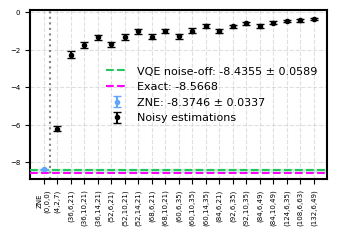

In [17]:
plot_zne_mul_var_single(
    data           = PROCESSED_SIM_DATA["ZNE-mul-var"]["muld3"],
    plot_colors    = {"zne": "#60a5fa", "noisy": "black",
                      "exact": "magenta", "noise_off": "#22c55e"},
    plot_file_name = "muld1_tmax20",
    output_dir     = OUTPUT_DIR,
    #plot_title     = "Multivariate ZNE",
    tick_fontsize  = 5,
    label_fontsize = 8,
    capsize  = 3,
    marker_size  = 3,
    border_width  = 1.5,
    legend_outside_plot = False,
    save_format    = ["png", "eps"],
    show_plot      = False,
    figsize               = FIG_SIZE_IEEE,
    dpi                   = 600,
)